In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Create dataset from image
data = {
    'Age': ['Youth', 'Youth', 'Middle-aged', 'Senior', 'Senior', 'Senior', 'Middle-aged',
            'Youth', 'Youth', 'Senior', 'Youth', 'Middle-aged', 'Middle-aged', 'Senior'],
    'Income': ['High', 'High', 'High', 'Medium', 'Low', 'Low', 'Low',
               'Medium', 'Low', 'High', 'Medium', 'Medium', 'High', 'Medium'],
    'Student': ['No', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes',
                'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No'],
    'Credit_Rating': ['Fair', 'Excellent', 'Fair', 'Fair', 'Fair', 'Excellent', 'Excellent',
                     'Fair', 'Fair', 'Fair', 'Excellent', 'Excellent', 'Fair', 'Excellent'],
    'Buys_Computer': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
                      'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}
df = pd.DataFrame(data)
df

,Age,Income,Student,Credit_Rating,Buys_Computer
0,Youth,High,No,Fair,No
1,Youth,High,No,Excellent,No
2,Middle-aged,High,No,Fair,Yes
3,Senior,Medium,No,Fair,Yes
4,Senior,Low,Yes,Fair,Yes
5,Senior,Low,Yes,Excellent,No
6,Middle-aged,Low,Yes,Excellent,Yes
7,Youth,Medium,No,Fair,No
8,Youth,Low,Yes,Fair,Yes
9,Senior,High,Yes,Fair,Yes


In [3]:
# Separate Features (X) and Target (y)
X = df.drop(columns=['Buys_Computer'])
y = df['Buys_Computer'].map({'No': 0, 'Yes': 1})

# Convert text columns into numbers (One-Hot Encoding)
X_encoded = pd.get_dummies(X)

# Train-Test Split (70% Training, 30% Testing)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

print(f"Training Samples: {len(X_train)} | Testing Samples: {len(X_test)}")

Training Samples: 9 | Testing Samples: 5


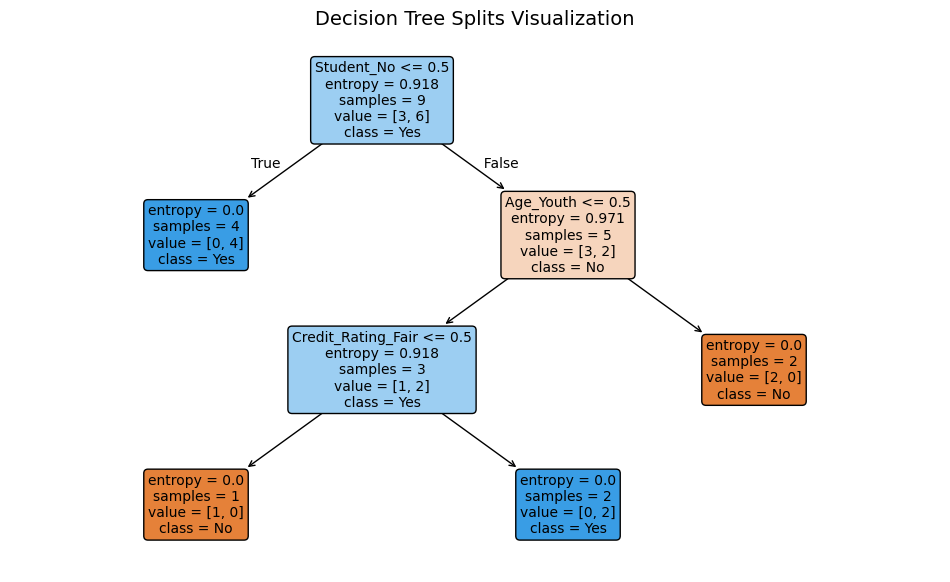

In [4]:
# Initialize and Train Decision Tree Classifier
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train, y_train)

# Visualize Decision Tree Splits
plt.figure(figsize=(12, 7))
plot_tree(
    model,
    feature_names=X_encoded.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Splits Visualization", fontsize=14)
plt.show()

=== FINAL EVALUATION METRICS ===
Accuracy : 60.00%
Precision: 66.67%
Recall   : 66.67%
F1-Score : 66.67%



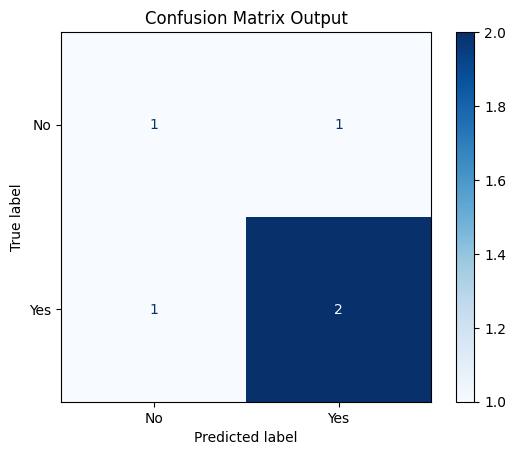

In [5]:
# Model Predictions on Test Data
y_pred = model.predict(X_test)

# Evaluation Metrics Calculation
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("=== FINAL EVALUATION METRICS ===")
print(f"Accuracy : {acc * 100:.2f}%")
print(f"Precision: {prec * 100:.2f}%")
print(f"Recall   : {rec * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%\n")

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix Output")
plt.show()

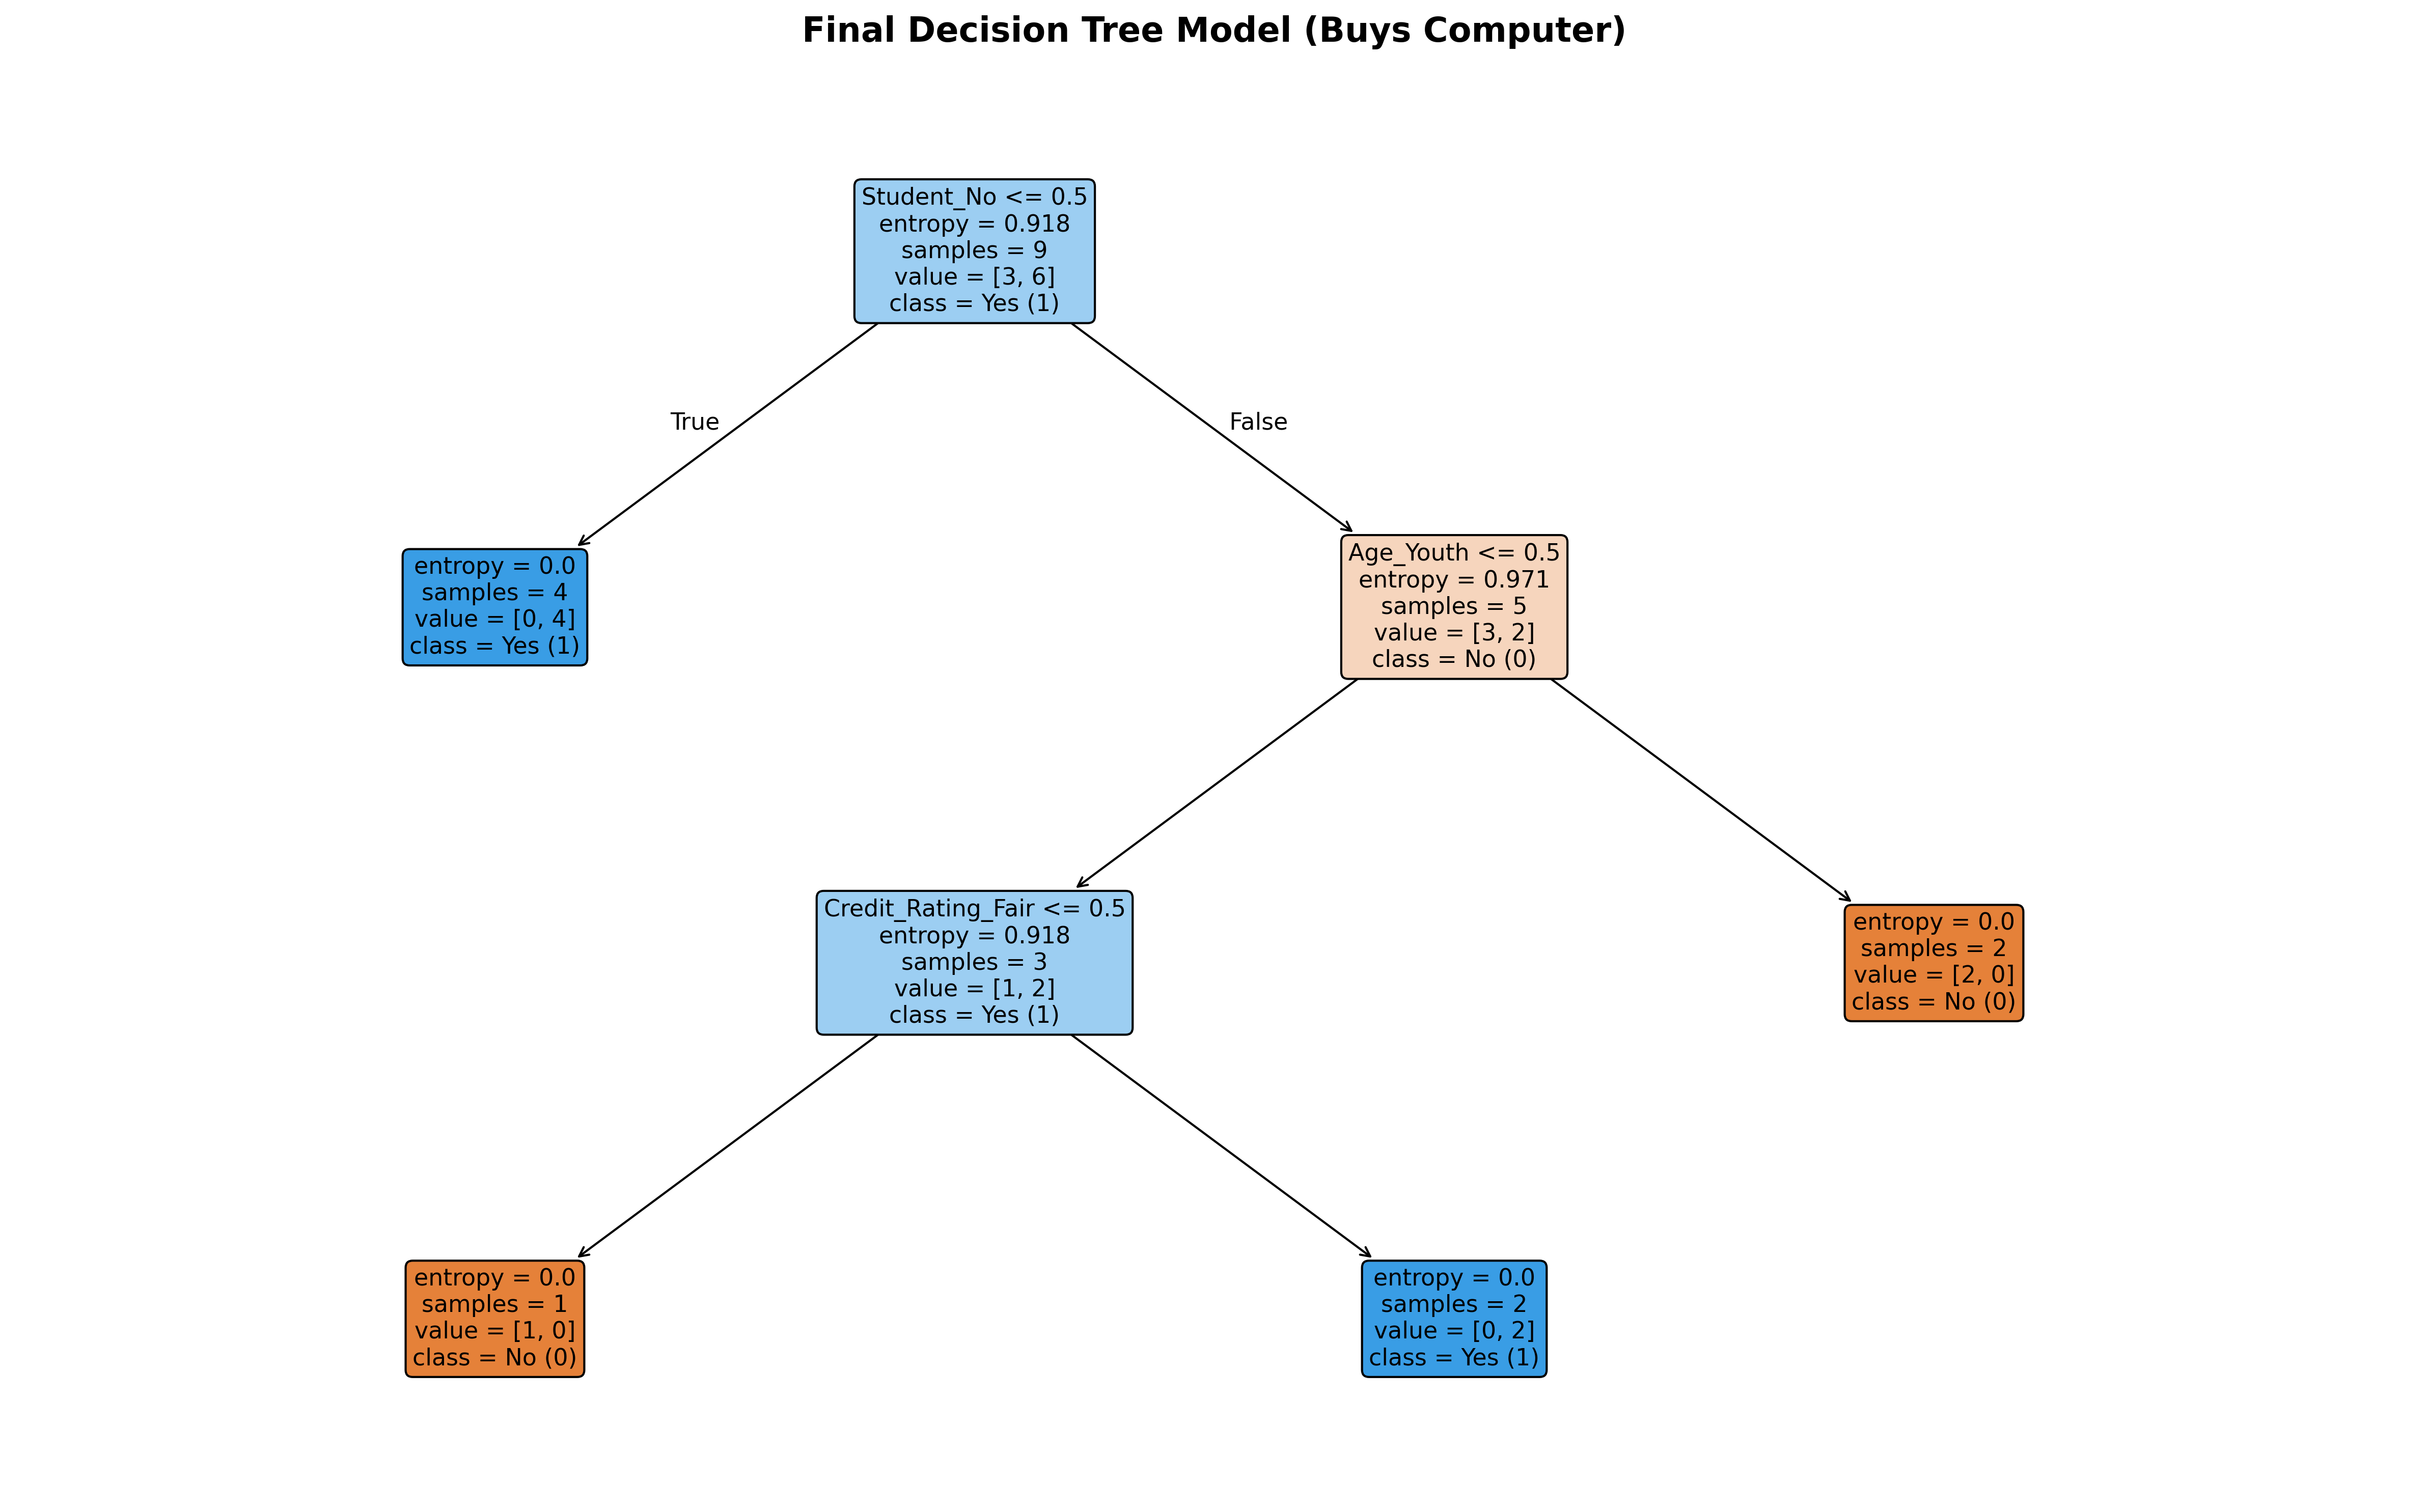

=== DECISION TREE RULES ===
|--- Student_No <= 0.50
|   |--- class: 1
|--- Student_No >  0.50
|   |--- Age_Youth <= 0.50
|   |   |--- Credit_Rating_Fair <= 0.50
|   |   |   |--- class: 0
|   |   |--- Credit_Rating_Fair >  0.50
|   |   |   |--- class: 1
|   |--- Age_Youth >  0.50
|   |   |--- class: 0



In [6]:
import matplotlib.pyplot as plt
from sklearn.tree import export_text, plot_tree
# 1. High-Resolution Tree Diagram Visualization
plt.figure(figsize=(16, 10), dpi=300)

plot_tree(
    model,
    feature_names=X_encoded.columns,
    class_names=["No (0)", "Yes (1)"],
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=11,
)

plt.title(
    "Final Decision Tree Model (Buys Computer)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()

# Save image file locally
plt.savefig("final_decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Textual Decision Rules Output
tree_rules = export_text(
    model, feature_names=list(X_encoded.columns)
)
print("=== DECISION TREE RULES ===")
print(tree_rules)